# Kernel Density Estimation (KDE) and Kernel Functions

- discrete and continuous probability,
- sums and integrals,
- histograms and KDE,
- the KDE formula,
- kernel functions,
- the roles of $x_i$, $n$, and bandwidth $h$,
- common kernel choices,
- the effects of changing $h$ and $n$.

In [1]:
"""Add plot template details"""

import matplotlib.pyplot as plt
import numpy as np


# Styling
base_fontsize = 18
linewidth = 1.5

niceblue = "#4d7da7"
nicered = "#e15656"
nicegray = "#6e6e6e"

plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

plt.rcParams["lines.linewidth"] = linewidth
plt.rcParams["axes.labelsize"] = base_fontsize
plt.rcParams["axes.titlesize"] = base_fontsize
plt.rcParams["xtick.labelsize"] = base_fontsize - 3
plt.rcParams["ytick.labelsize"] = base_fontsize - 3

plt.rcParams["legend.fontsize"] = base_fontsize - 4
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.facecolor"] = "white"
plt.rcParams["legend.edgecolor"] = "#e0e0e0"
plt.rcParams["legend.loc"] = "upper right"

## Core intuition

### Discrete vs continuous

For a **discrete** random variable, probabilities are added with a sum:

$$
P(X \in A)=\sum_{x\in A}P(X=x)
$$

For a **continuous** random variable, probabilities are computed with an integral:

$$
P(X\in A)=\int_A f(x)\,dx
$$

### Histogram vs KDE

A histogram groups observations into bins.

A **Kernel Density Estimator (KDE)** is a smooth, continuous alternative to a histogram.

The central idea is:

$$
\text{data points}
\rightarrow
\text{local kernel curves}
\rightarrow
\text{average the curves}
\rightarrow
\text{smooth density estimate}
$$


## KDE formula

For observations $x_1,x_2,\ldots,x_n$, the KDE is

$$
\hat f_h(x)
=
\frac{1}{nh}
\sum_{i=1}^{n}
K\left(\frac{x-x_i}{h}\right)
$$

where:

- $x_i$: the $i$-th observed data value,
- $n$: the number of observations,
- $K$: the chosen kernel function,
- $h$: the bandwidth,
- $\hat f_h(x)$: the estimated density at $x$.

### What each part means

- The **kernel** determines the shape placed around every observation.
- The **bandwidth** $h$ controls the width of that shape.
- The **sample size** $n$ is the number of observations in the dataset.

Important distinction:

- $h$ is a tuning parameter.
- $n$ comes from the amount of available data.


## Gaussian kernel

A common choice is the **Gaussian kernel**:

$$
K(u)=\frac{1}{\sqrt{2\pi}}e^{-u^2/2}
$$

Substituting it into the KDE formula gives:

$$
\hat f_h(x)
=
\frac{1}{nh\sqrt{2\pi}}
\sum_{i=1}^{n}
\exp\left(
-\frac{(x-x_i)^2}{2h^2}
\right)
$$

Interpretation:

- each observation receives a bell-shaped curve,
- that curve is centered at $x_i$,
- nearby positions receive higher weight than distant positions.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Dict

In [3]:
# Example observations used throughout the notebook
observations = np.array([1.0, 2.0, 2.5, 4.0, 5.0])
n_samples = observations.size
bandwidth = 0.6
x_grid = np.linspace(-0.5, 6.5, 1000)

print(f"Observations: {observations}")
print(f"n = {n_samples}")
print(f"h = {bandwidth}")

Observations: [1.  2.  2.5 4.  5. ]
n = 5
h = 0.6


## Common kernel functions

Different kernels define different local shapes around each observation.

### Gaussian

$$
K(u)=\frac{1}{\sqrt{2\pi}}e^{-u^2/2}
$$

### Uniform

$$
K(u)=
\begin{cases}
\frac{1}{2}, & |u|\leq 1,\\
0, & |u|>1
\end{cases}
$$

### Triangular

$$
K(u)=
\begin{cases}
1-|u|, & |u|\leq 1,\\
0, & |u|>1
\end{cases}
$$

### Epanechnikov

$$
K(u)=
\begin{cases}
\frac{3}{4}(1-u^2), & |u|\leq 1,\\
0, & |u|>1
\end{cases}
$$

### Biweight

$$
K(u)=
\begin{cases}
\frac{15}{16}(1-u^2)^2, & |u|\leq 1,\\
0, & |u|>1
\end{cases}
$$

### Cosine

$$
K(u)=
\begin{cases}
\frac{\pi}{4}\cos\left(\frac{\pi u}{2}\right), & |u|\leq 1,\\
0, & |u|>1
\end{cases}
$$

The constants normalize the kernels so that their total area is one:

$$
\int_{-\infty}^{\infty}K(u)\,du=1
$$


In [4]:
def gaussian_kernel(u: np.ndarray) -> np.ndarray:
    return np.exp(-0.5 * u**2) / np.sqrt(2.0 * np.pi)


def uniform_kernel(u: np.ndarray) -> np.ndarray:
    return 0.5 * (np.abs(u) <= 1.0)


def triangular_kernel(u: np.ndarray) -> np.ndarray:
    return np.maximum(1.0 - np.abs(u), 0.0)


def epanechnikov_kernel(u: np.ndarray) -> np.ndarray:
    values = 0.75 * (1.0 - u**2)
    return np.where(np.abs(u) <= 1.0, values, 0.0)


def biweight_kernel(u: np.ndarray) -> np.ndarray:
    values = (15.0 / 16.0) * (1.0 - u**2) ** 2
    return np.where(np.abs(u) <= 1.0, values, 0.0)


def cosine_kernel(u: np.ndarray) -> np.ndarray:
    values = (np.pi / 4.0) * np.cos((np.pi * u) / 2.0)
    return np.where(np.abs(u) <= 1.0, values, 0.0)


kernel_functions: Dict[str, Callable[[np.ndarray], np.ndarray]] = {
    "Gaussian": gaussian_kernel,
    "Uniform": uniform_kernel,
    "Triangular": triangular_kernel,
    "Epanechnikov": epanechnikov_kernel,
    "Biweight": biweight_kernel,
    "Cosine": cosine_kernel,
}

## Plot the kernel functions themselves

The following plot compares the shapes of $K(u)$ directly, before applying them to any dataset.


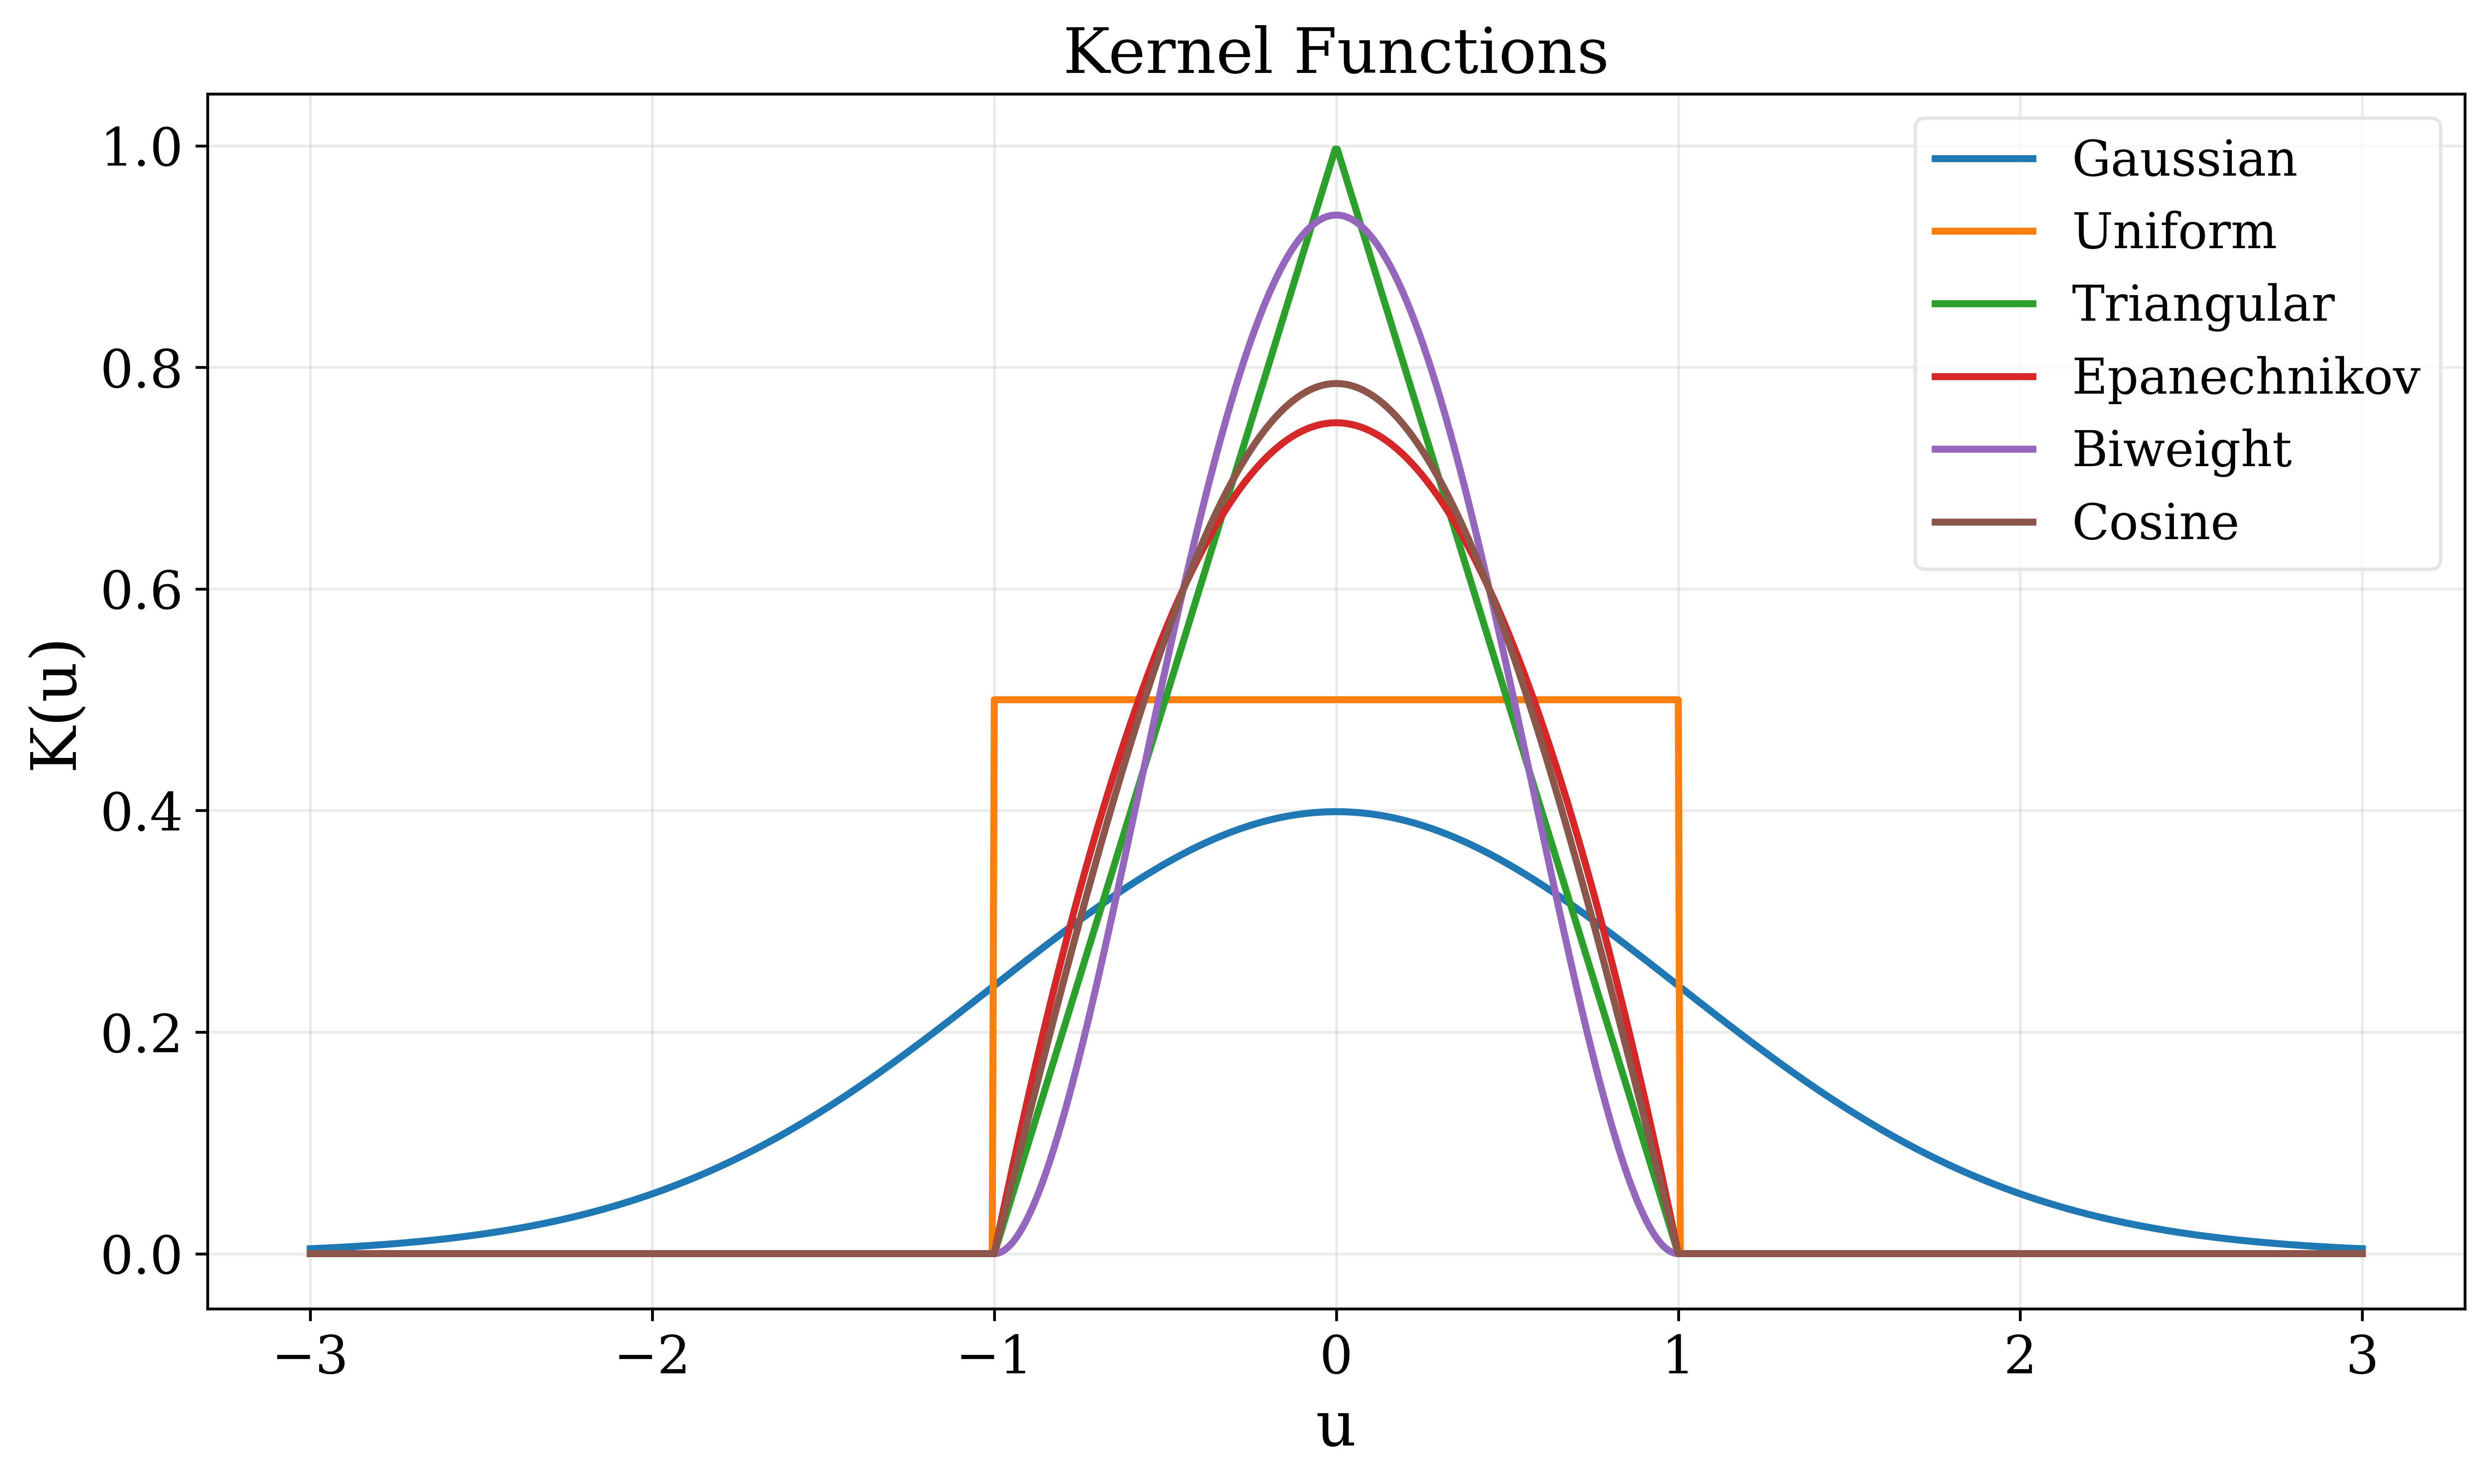

In [5]:
u_grid = np.linspace(-3.0, 3.0, 1000)

plt.figure(figsize=(10, 6))
for kernel_name, kernel_function in kernel_functions.items():
    plt.plot(u_grid, kernel_function(u_grid), linewidth=2, label=kernel_name)

plt.xlabel("u")
plt.ylabel("K(u)")
plt.title("Kernel Functions")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Same data, different kernels

We now keep the observations and bandwidth $h$ fixed and change only the kernel function.

This isolates how the kernel shape affects the final density estimate.


In [6]:
def kde_estimate(
    x_grid: np.ndarray,
    observations: np.ndarray,
    bandwidth: float,
    kernel_function: Callable[[np.ndarray], np.ndarray],
) -> np.ndarray:
    density = np.zeros_like(x_grid, dtype=float)

    for observation in observations:
        u = (x_grid - observation) / bandwidth
        density += kernel_function(u)

    return density / (observations.size * bandwidth)

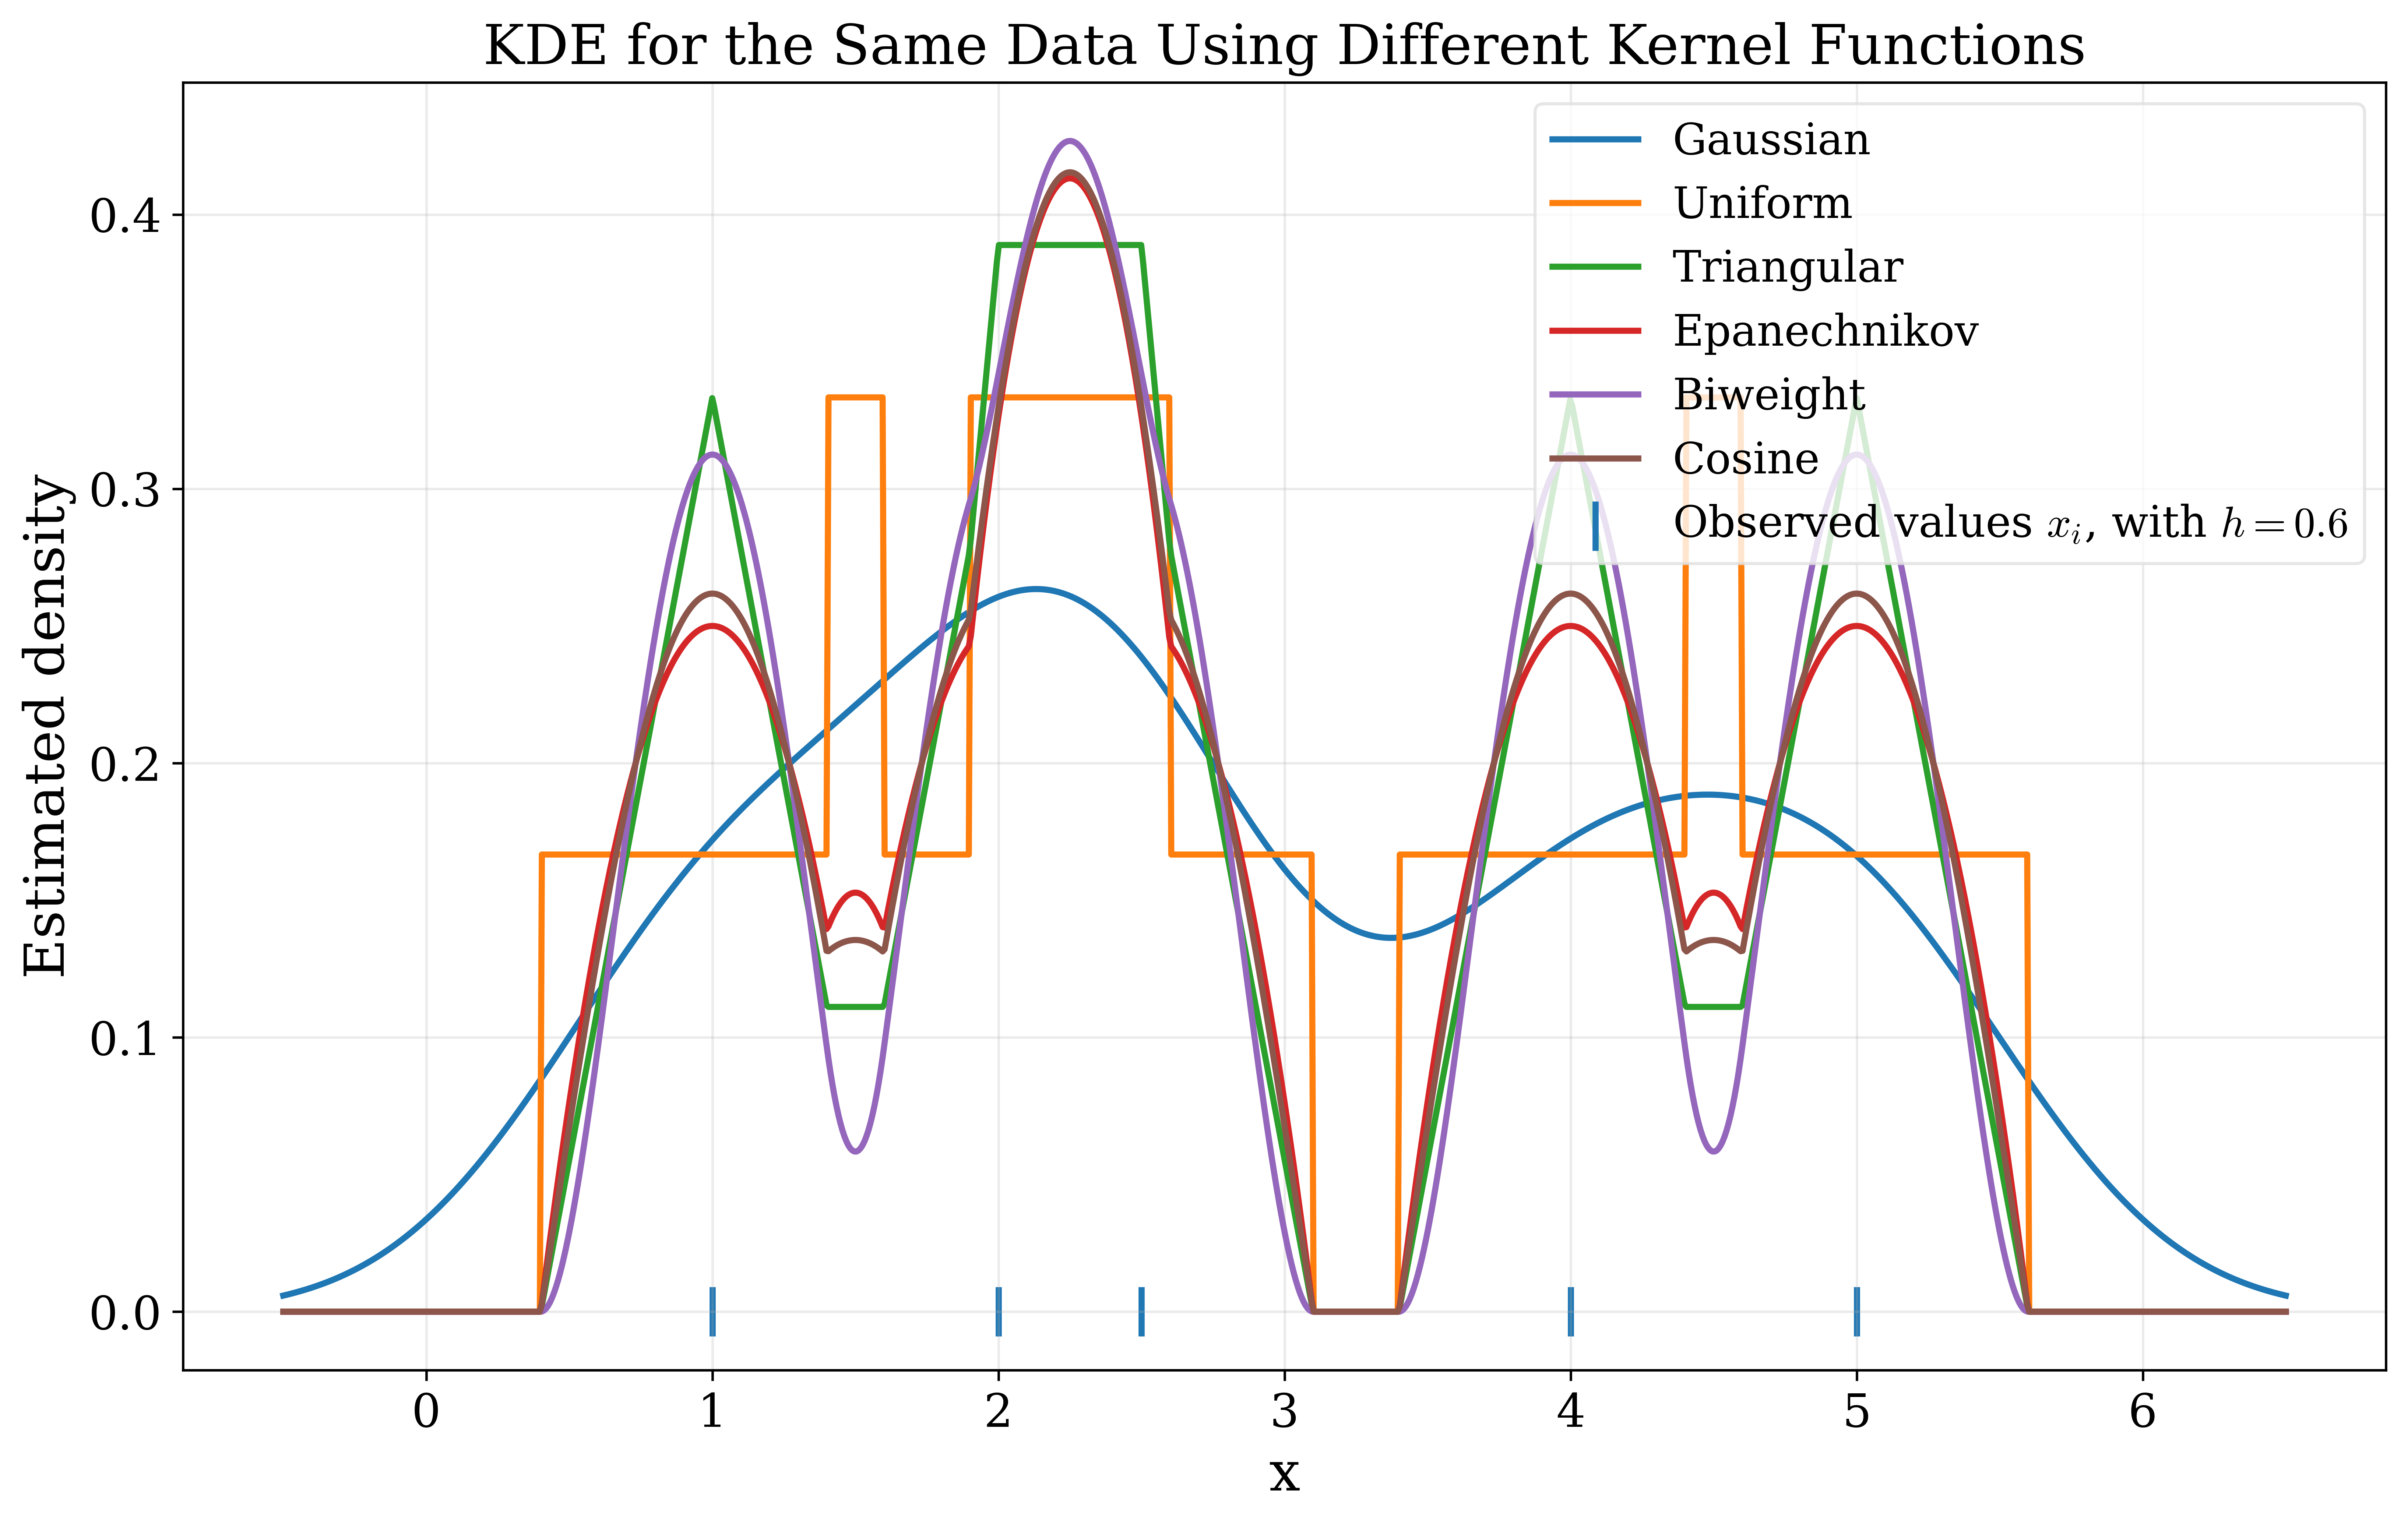

In [7]:
plt.figure(figsize=(11, 7))
for kernel_name, kernel_function in kernel_functions.items():
    density = kde_estimate(
        x_grid=x_grid,
        observations=observations,
        bandwidth=bandwidth,
        kernel_function=kernel_function,
    )
    plt.plot(x_grid, density, linewidth=2, label=kernel_name)

plt.scatter(
    observations,
    np.zeros_like(observations),
    marker="|",
    s=260,
    linewidths=2,
    label=rf"Observed values $x_i$, with $h={bandwidth}$",
)

plt.xlabel("x")
plt.ylabel("Estimated density")
plt.title("KDE for the Same Data Using Different Kernel Functions")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- The broad distribution pattern remains similar across kernels.
- The exact local shape changes slightly.
- The Uniform kernel creates block-like changes.
- Smooth kernels such as Gaussian, Biweight, and Cosine create smoother transitions.
- In practical KDE work, bandwidth selection usually affects the result more than kernel selection.


## Effect of bandwidth $h$ with fixed data

We keep the observations fixed and compare three bandwidth values.


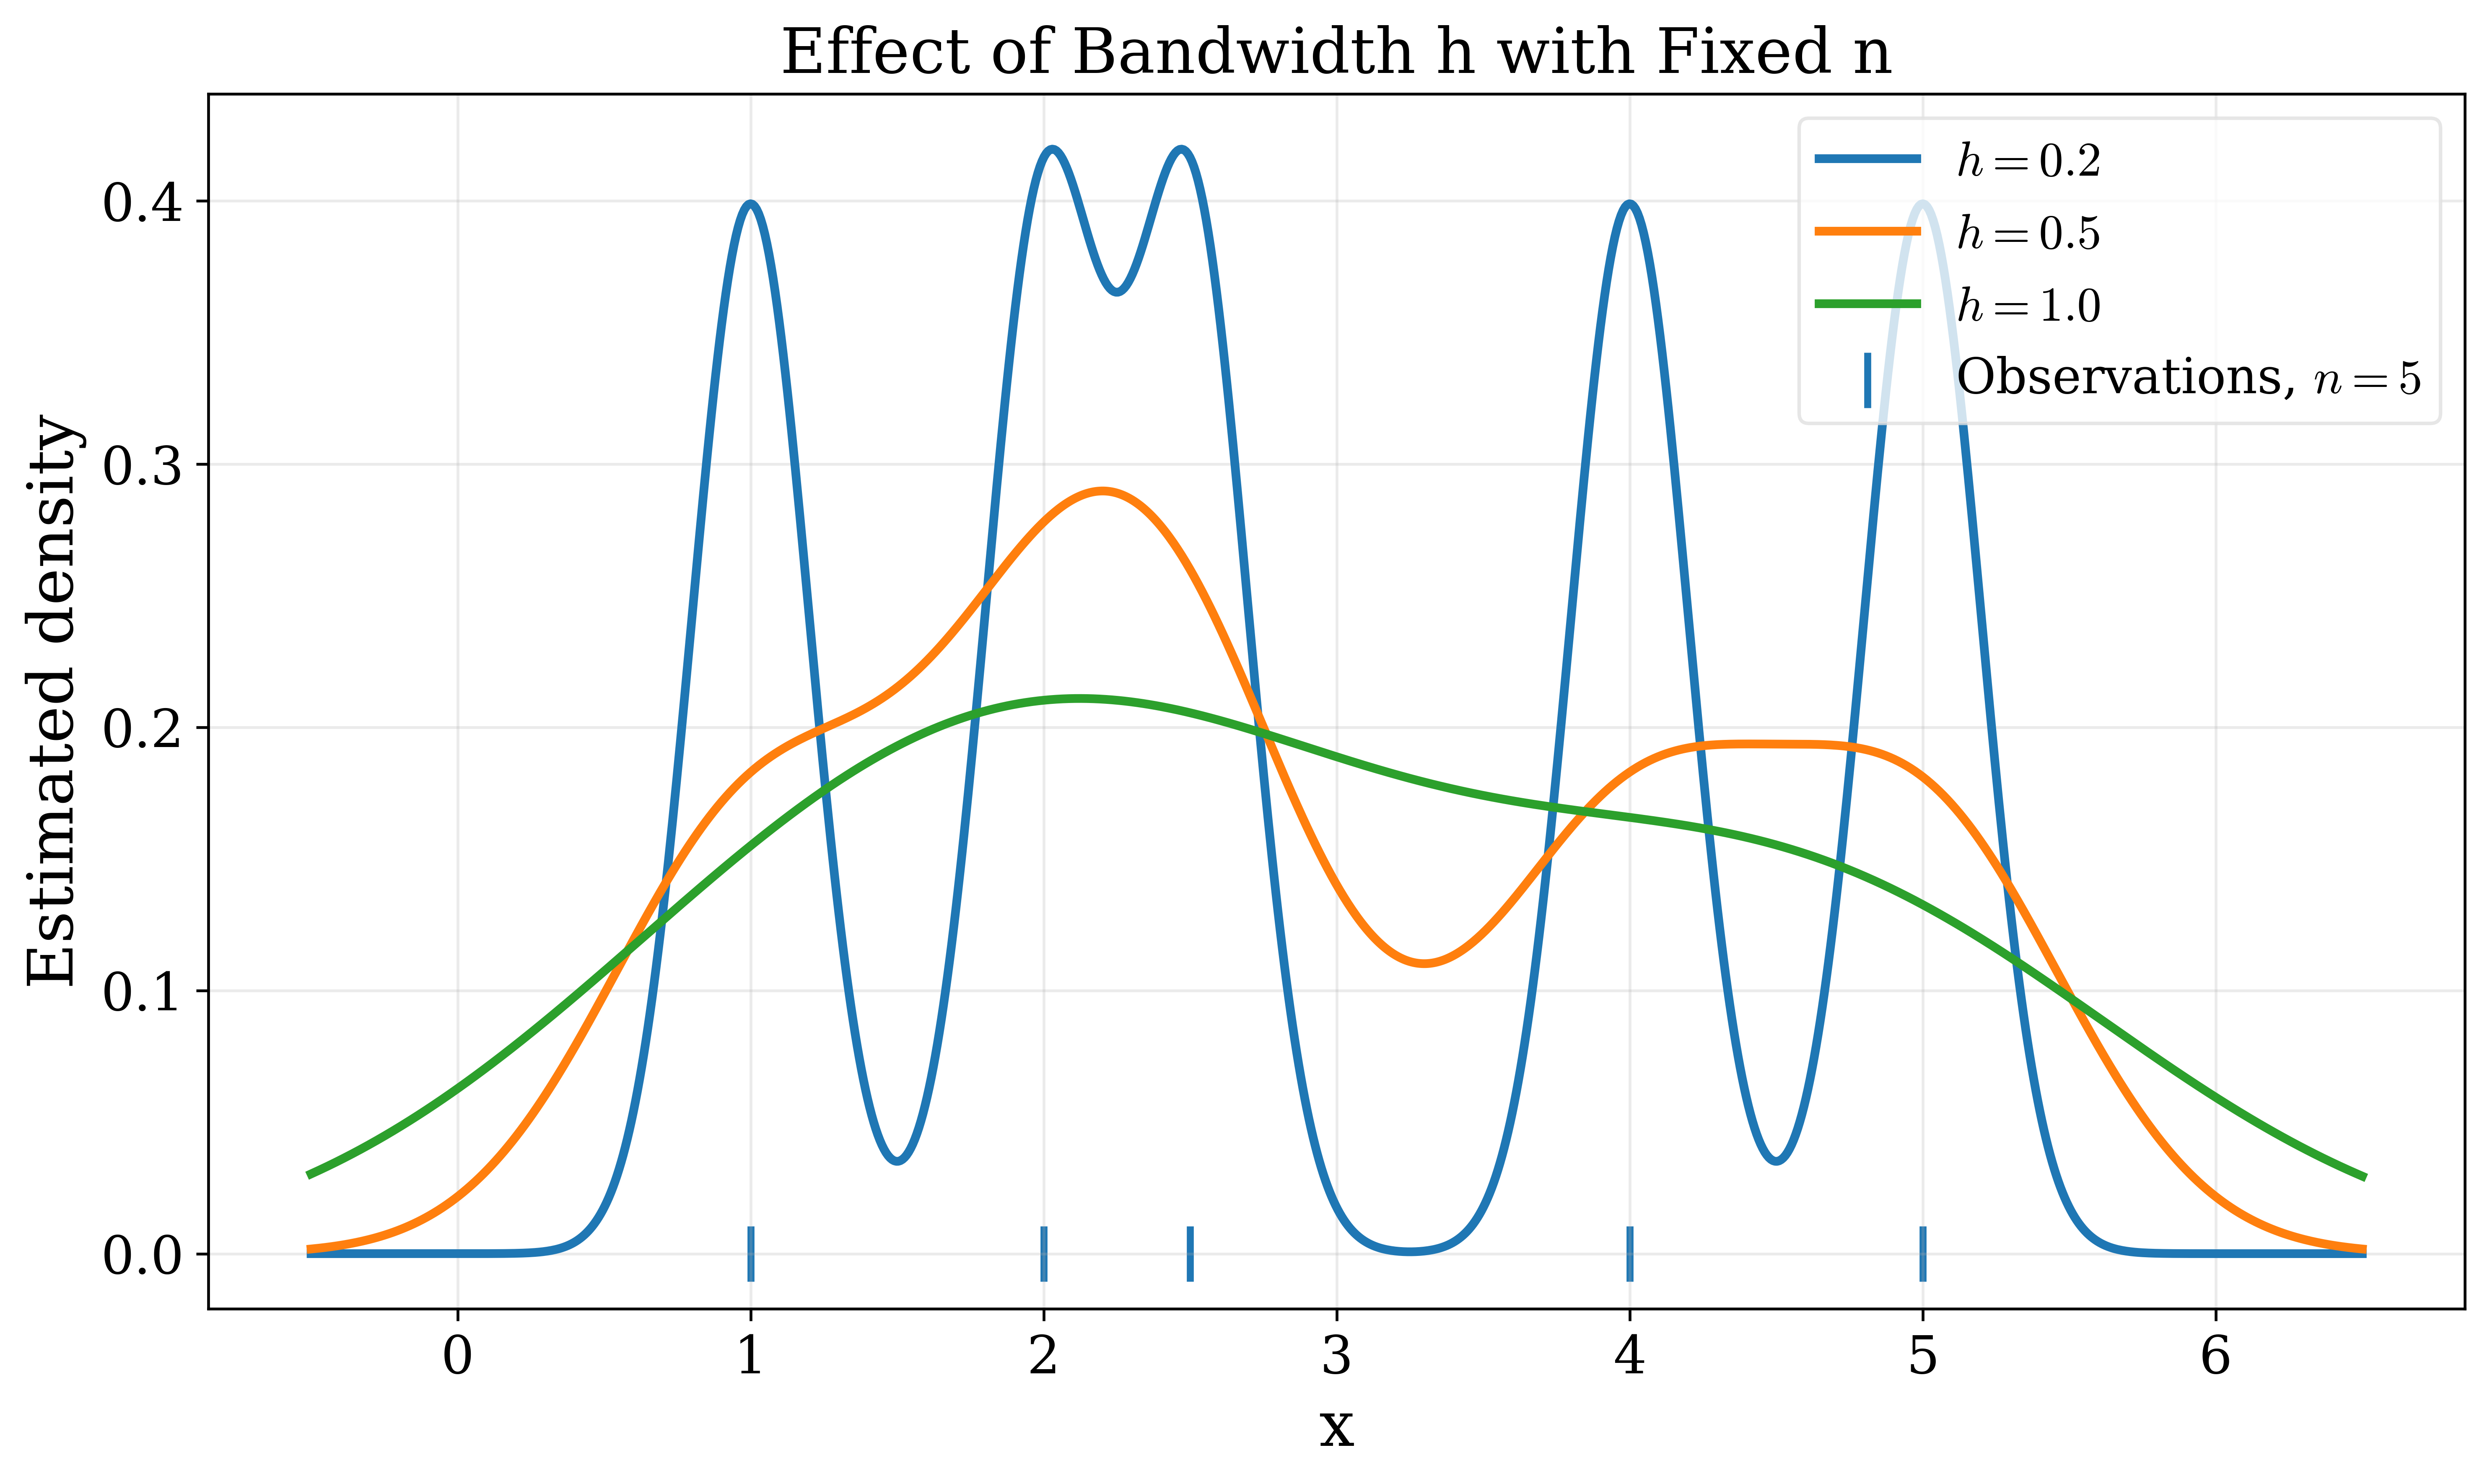

In [8]:
bandwidth_values = [0.2, 0.5, 1.0]

plt.figure(figsize=(10, 6))
for h_value in bandwidth_values:
    density = kde_estimate(
        x_grid=x_grid,
        observations=observations,
        bandwidth=h_value,
        kernel_function=gaussian_kernel,
    )
    plt.plot(x_grid, density, linewidth=2.5, label=rf"$h={h_value}$")

plt.scatter(
    observations,
    np.zeros_like(observations),
    marker="|",
    s=250,
    linewidths=2,
    label=rf"Observations, $n={observations.size}$",
)

plt.xlabel("x")
plt.ylabel("Estimated density")
plt.title("Effect of Bandwidth h with Fixed n")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- Small $h$: narrow kernels, many local peaks, and greater sensitivity to noise.
- Medium $h$: a more balanced estimate.
- Large $h$: wider kernels and a smoother estimate, but potentially too much lost detail.

Therefore:

$$
\boxed{h\text{ controls the amount of smoothing}}
$$


## Effect of sample size $n$ with fixed bandwidth

Now we keep the bandwidth fixed and progressively include more observations.

Remember:

$$
n=\text{number of observations}
$$

Unlike $h$, the sample size is not a smoothing parameter. It is determined by how much data is available.


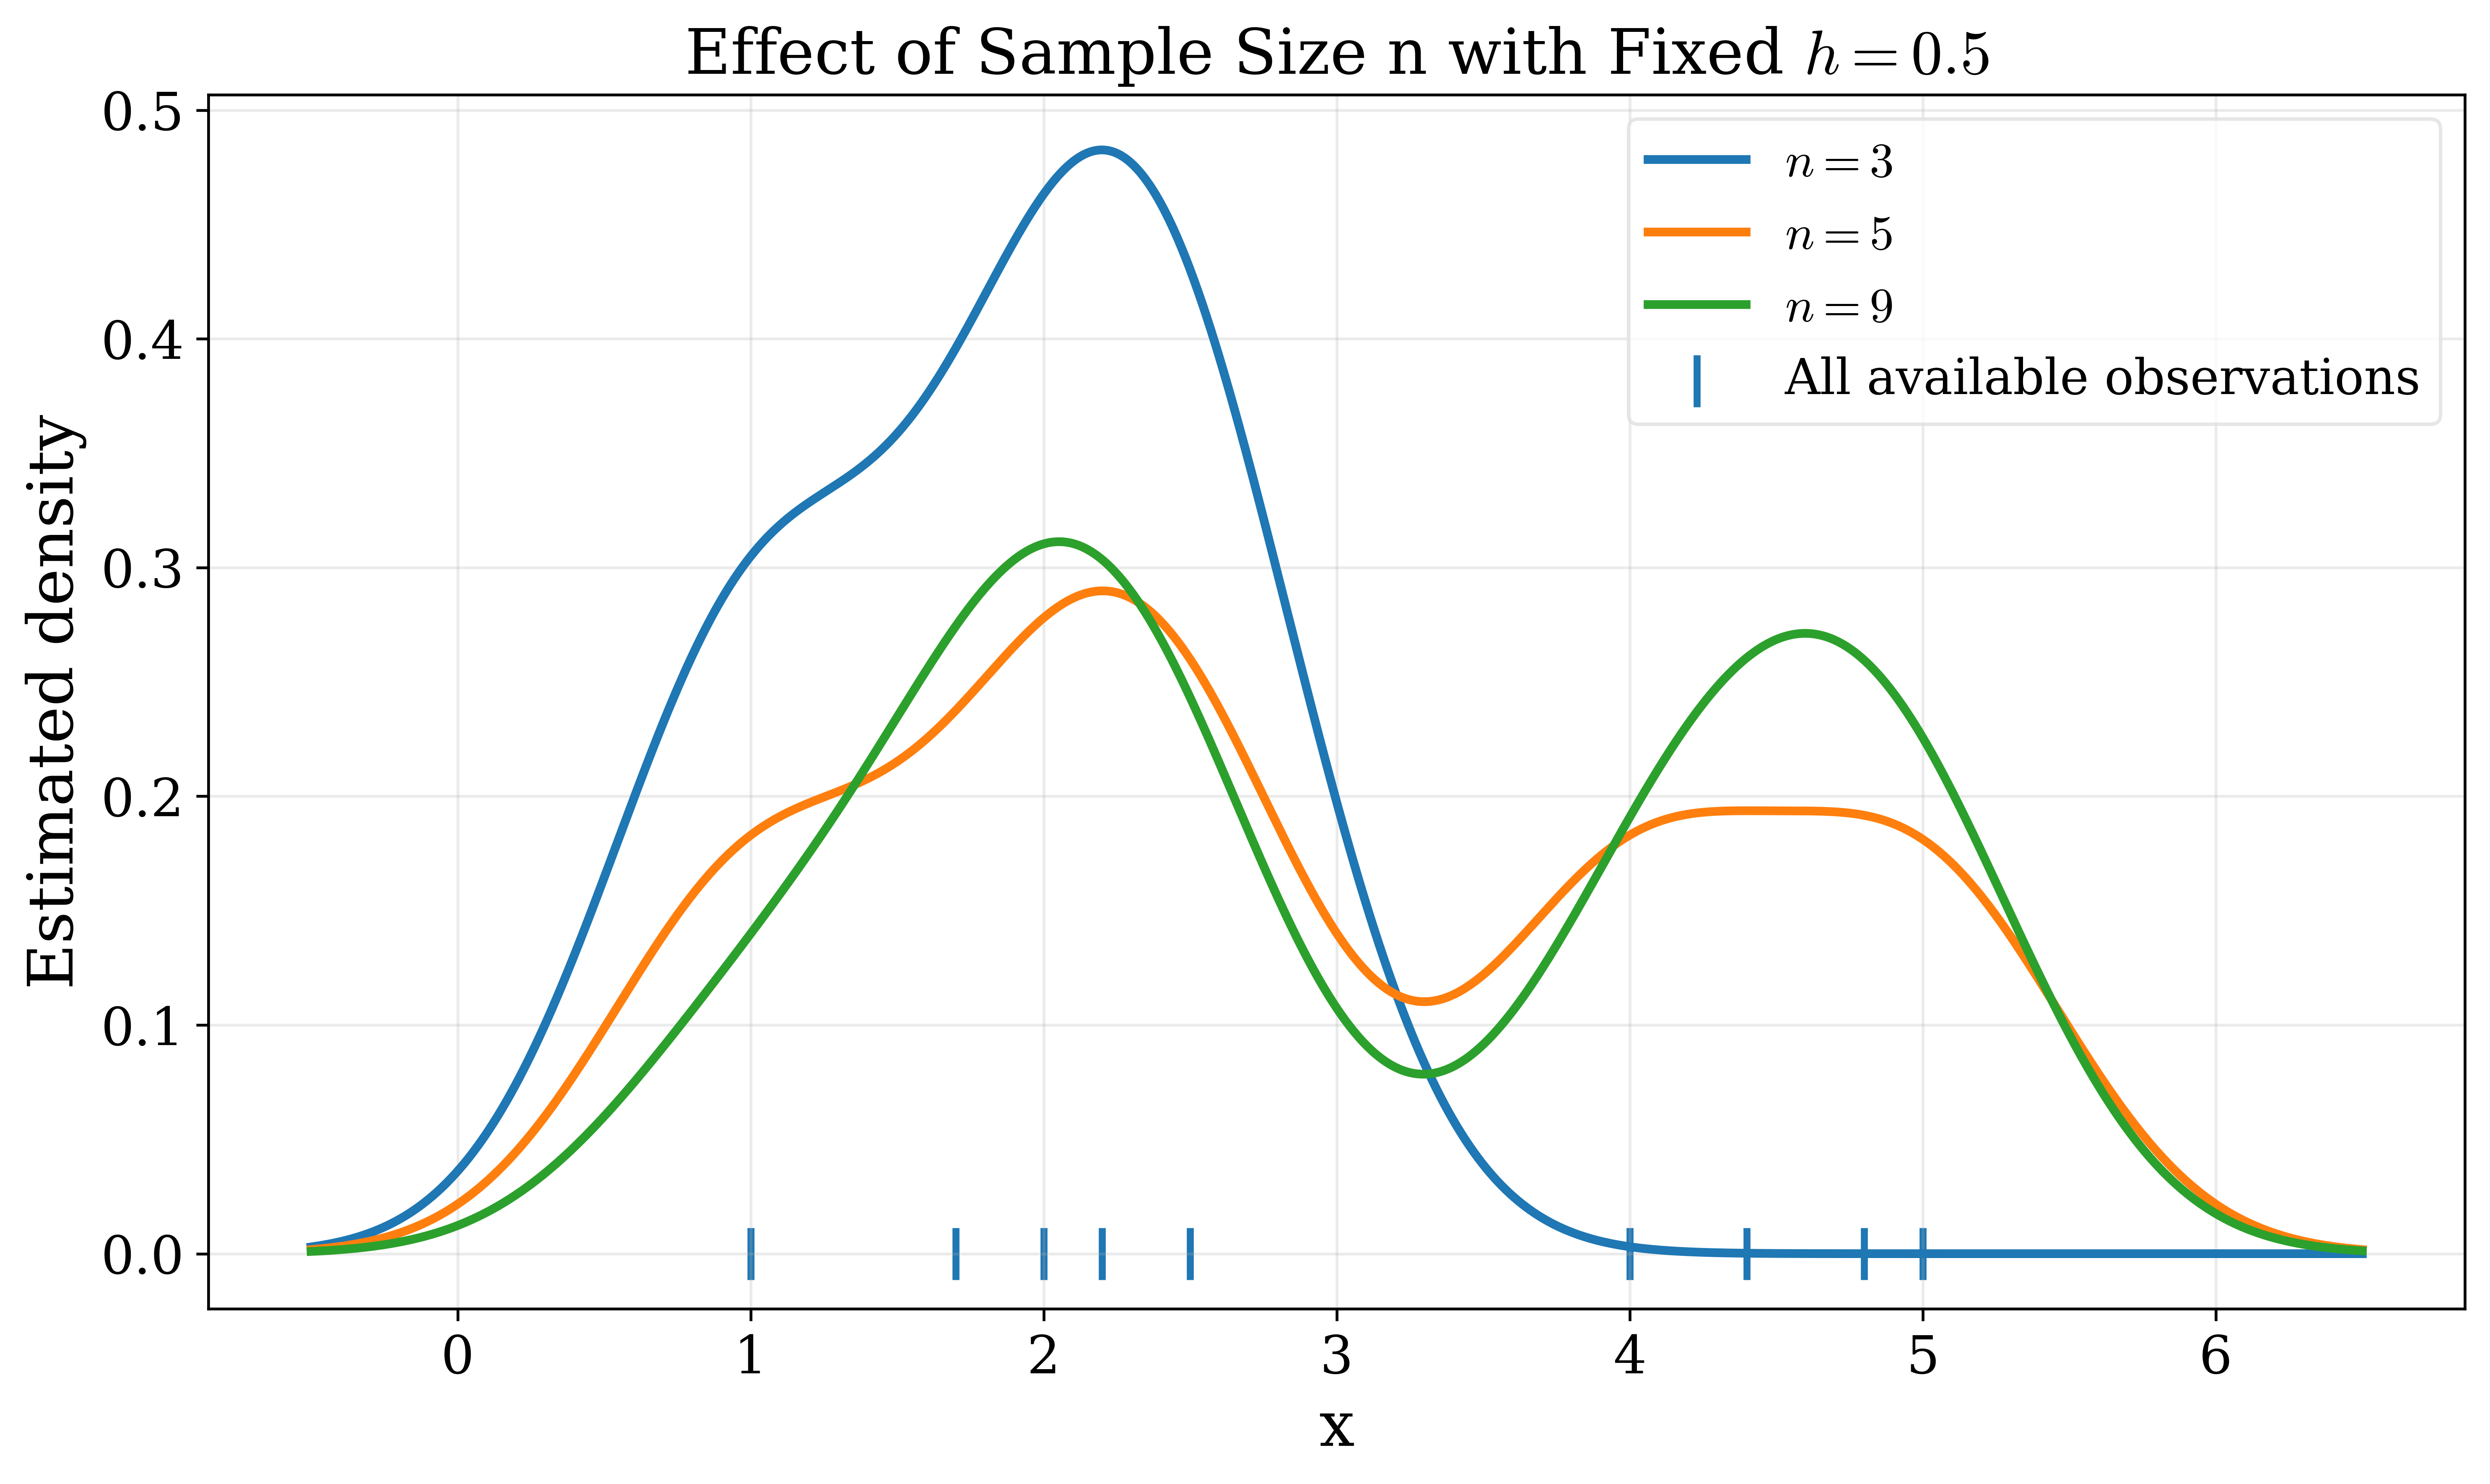

In [9]:
all_observations = np.array([1.0, 2.0, 2.5, 4.0, 5.0, 1.7, 2.2, 4.4, 4.8])
sample_sizes = [3, 5, 9]
fixed_h = 0.5

plt.figure(figsize=(10, 6))
for sample_size in sample_sizes:
    current_observations = all_observations[:sample_size]
    density = kde_estimate(
        x_grid=x_grid,
        observations=current_observations,
        bandwidth=fixed_h,
        kernel_function=gaussian_kernel,
    )
    plt.plot(x_grid, density, linewidth=2.5, label=rf"$n={sample_size}$")

plt.scatter(
    all_observations,
    np.zeros_like(all_observations),
    marker="|",
    s=220,
    linewidths=2,
    label="All available observations",
)

plt.xlabel("x")
plt.ylabel("Estimated density")
plt.title(r"Effect of Sample Size n with Fixed $h=0.5$")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

- Smaller $n$: the estimate is based on less evidence and can be unstable.
- Larger $n$: the estimate is usually more reliable and better represents the underlying distribution.

Therefore:

$$
\boxed{n\text{ controls how many observations contribute}}
$$

while

$$
\boxed{h\text{ controls how widely each observation spreads}}
$$


## What one kernel does

For a single observation $x_i$, the kernel assigns:

- a high weight to positions near $x_i$,
- a low weight to positions far from $x_i$.

The main purpose of a kernel is therefore:

$$
\boxed{\text{spread each observed point over a nearby region}}
$$

This allows discrete observations to produce a smooth estimate of an underlying continuous density.


## Final summary

### Most important ideas

1. Discrete probability commonly uses sums, while continuous probability uses integrals.
2. A histogram uses bins; KDE creates a smooth density estimate.
3. The KDE formula is

$$
\hat f_h(x)
=
\frac{1}{nh}
\sum_{i=1}^{n}
K\left(\frac{x-x_i}{h}\right)
$$

4. A kernel determines the local shape placed around each observation.
5. The bandwidth $h$ controls the width of every local kernel.
6. Small $h$ produces a more detailed, wiggly estimate.
7. Large $h$ produces a smoother estimate that may hide useful structure.
8. The sample size $n$ is the number of observations, not a kernel-shape parameter.
9. Common kernels include Gaussian, Uniform, Triangular, Epanechnikov, Biweight, and Cosine.
10. In practice, bandwidth selection usually matters more than the exact kernel choice.

The full KDE process is:

$$
\text{observations}
\rightarrow
\text{one kernel centered at each }x_i
\rightarrow
\text{sum and average the kernels}
\rightarrow
\text{final KDE}
$$
